## 1. Imports and AWS setup

In [40]:
import os
import json
import tarfile
import warnings
from pathlib import Path

import boto3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sagemaker
from sagemaker import get_execution_role
from sagemaker.feature_store.feature_group import FeatureGroup
from sagemaker.session import Session
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

region = boto3.Session().region_name
boto_session = boto3.Session(region_name=region)
sagemaker_client = boto_session.client(
    service_name="sagemaker",
    region_name=region
)
featurestore_runtime = boto_session.client(
    service_name="sagemaker-featurestore-runtime", region_name=region
)

feature_store_session = Session(
    boto_session=boto_session,
    sagemaker_client=sagemaker_client,
    sagemaker_featurestore_runtime_client=featurestore_runtime,
)


role = get_execution_role()
default_s3_bucket_name = feature_store_session.default_bucket()
prefix = "carepath-analytics/feature-store"

athena_s3_staging_dir = f"s3://{default_s3_bucket_name}/athena/staging"

print(f"AWS Region: {region}")
print(f"Execution Role ARN: {role}")
print(f"Feature Store S3 Prefix: s3://{default_s3_bucket_name}/{prefix}")
print(f"Athena Connection S3 Staging Dir: {athena_s3_staging_dir}")

AWS Region: us-east-1
Execution Role ARN: arn:aws:iam::545290732881:role/LabRole
Feature Store S3 Prefix: s3://sagemaker-us-east-1-545290732881/carepath-analytics/feature-store
Athena Connection S3 Staging Dir: s3://sagemaker-us-east-1-545290732881/athena/staging


# Data Engineering

- `diabetic_data.csv` - main encounter data
- `IDS_mapping.csv` - lookup values for admission type, discharge disposition, and admission source

## 2. Load both project data sources

In [2]:
data_candidates = [
    Path("../../data"),
    Path("../data"),
    Path("data"),
    Path("/home/sagemaker-user/diabetes-readmission-prediction/data"),
]

data_dir = next(
    (
        p for p in data_candidates
        if (p / "diabetic_data.csv").exists() and (p / "IDS_mapping.csv").exists()
    ),
    None,
)

if data_dir is None:
    raise FileNotFoundError(
        "Could not find diabetic_data.csv and IDS_mapping.csv. "
        "Update data_candidates with the correct project data folder."
    )

diabetes_path = data_dir / "diabetic_data.csv"
mapping_path = data_dir / "IDS_mapping.csv"

raw_df = pd.read_csv(diabetes_path)

print("Data folder:", data_dir)
print("Main dataset shape:", raw_df.shape)
raw_df.head(3)

Data folder: ../../data
Main dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## 3. Read `IDS_mapping.csv`

The lookup file contains three mapping sections in one CSV:

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`

The helper below reads each section and creates a dictionary.

In [3]:
def load_id_mappings(path):
    mappings = {}
    current_key = None

    with open(path, "r", encoding="utf-8-sig") as f:
        lines = [line.rstrip("\n\r") for line in f]

    valid_headers = {
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id",
    }

    for line in lines:
        if not line.strip():
            continue

        parts = line.split(",", 1)
        first = parts[0].strip()

        if first in valid_headers:
            current_key = first
            mappings[current_key] = {}
            continue

        if current_key is None:
            continue

        if first == "":
            current_key = None
            continue

        if len(parts) < 2:
            continue

        try:
            key = int(first)
        except ValueError:
            continue

        description = parts[1].strip().strip('"').strip()

        if description.upper() in {
            "NULL",
            "NOT MAPPED",
            "UNKNOWN/INVALID",
            "NOT AVAILABLE",
        }:
            description = "Unknown"

        mappings[current_key][key] = description

    return mappings

id_mappings = load_id_mappings(mapping_path)

for name, mapping in id_mappings.items():
    print(name, "->", len(mapping), "mapped values")
    print(list(mapping.items())[:5])
    print()

admission_type_id -> 8 mapped values
[(1, 'Emergency'), (2, 'Urgent'), (3, 'Elective'), (4, 'Newborn'), (5, 'Unknown')]

discharge_disposition_id -> 30 mapped values
[(1, 'Discharged to home'), (2, 'Discharged/transferred to another short term hospital'), (3, 'Discharged/transferred to SNF'), (4, 'Discharged/transferred to ICF'), (5, 'Discharged/transferred to another type of inpatient care institution')]

admission_source_id -> 25 mapped values
[(1, 'Physician Referral'), (2, 'Clinic Referral'), (3, 'HMO Referral'), (4, 'Transfer from a hospital'), (5, 'Transfer from a Skilled Nursing Facility (SNF)')]



## 4. Store raw data in Amazon S3

Uses Amazon S3 as the main project storage.  
The original source files are uploaded to a `raw/` location before preprocessing.

In [10]:
session = sagemaker.Session()
bucket = session.default_bucket()

PROJECT_PREFIX = "carepath-analytics"
RAW_PREFIX = f"{PROJECT_PREFIX}/raw"

raw_main_s3_uri = session.upload_data(
    path=str(diabetes_path),
    bucket=bucket,
    key_prefix=RAW_PREFIX,
)

raw_mapping_s3_uri = session.upload_data(
    path=str(mapping_path),
    bucket=bucket,
    key_prefix=RAW_PREFIX,
)

print("Raw main dataset:", raw_main_s3_uri)
print("Raw ID mapping file:", raw_mapping_s3_uri)

Raw main dataset: s3://sagemaker-us-east-1-545290732881/carepath-analytics/raw/diabetic_data.csv
Raw ID mapping file: s3://sagemaker-us-east-1-545290732881/carepath-analytics/raw/IDS_mapping.csv


## 5. Clean and preprocess the data
- Convert placeholder values to consistent missing/unknown values
- Convert the original readmission target into a binary 30-day flag
- Translate coded hospital ID fields using `IDS_mapping.csv`
- Group high-cardinality diagnosis codes into broader clinical categories
- Remove duplicate encounters

In [11]:
df = raw_df.copy()

# Standardize missing placeholders
df.replace("?", "Unknown", inplace=True)
df.fillna("Unknown", inplace=True)

# Remove duplicate encounter records
df = df.drop_duplicates(subset=["encounter_id"]).reset_index(drop=True)

# Binary target: 1 = readmitted within 30 days, 0 = otherwise
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

# Map coded fields to readable descriptions using IDS_mapping.csv
df["admission_type"] = (
    pd.to_numeric(df["admission_type_id"], errors="coerce")
    .map(id_mappings["admission_type_id"])
    .fillna("Unknown")
)

df["discharge_disposition"] = (
    pd.to_numeric(df["discharge_disposition_id"], errors="coerce")
    .map(id_mappings["discharge_disposition_id"])
    .fillna("Unknown")
)

df["admission_source"] = (
    pd.to_numeric(df["admission_source_id"], errors="coerce")
    .map(id_mappings["admission_source_id"])
    .fillna("Unknown")
)

def categorize_icd9(code):
    code_str = str(code).strip().upper()

    if not code_str or code_str in {"UNKNOWN", "NAN", "NONE"}:
        return "Unknown"

    if code_str.startswith(("V", "E")):
        return "Other"

    try:
        value = int(code_str.split(".")[0][:3])
    except ValueError:
        return "Other"

    if (390 <= value <= 459) or value == 785:
        return "Circulatory"
    elif (460 <= value <= 519) or value == 786:
        return "Respiratory"
    elif (520 <= value <= 579) or value == 787:
        return "Digestive"
    elif value == 250:
        return "Diabetes"
    elif 800 <= value <= 999:
        return "Injury"
    elif 710 <= value <= 739:
        return "Musculoskeletal"
    elif (580 <= value <= 629) or value == 788:
        return "Genitourinary"
    elif 140 <= value <= 239:
        return "Neoplasms"
    else:
        return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[f"{col}_group"] = df[col].apply(categorize_icd9)

print("Processed shape:", df.shape)
print("30-day readmission count:", int(df["readmitted_30d"].sum()))
print("30-day readmission rate:", round(df["readmitted_30d"].mean(), 4))

Processed shape: (101766, 57)
30-day readmission count: 11357
30-day readmission rate: 0.1116


## 6. Save processed data to S3

The processed dataset is stored separately from the raw files, which keeps the workflow reproducible.

In [13]:
PROCESSED_PREFIX = f"{PROJECT_PREFIX}/processed"

processed_dir = Path("artifacts")
processed_dir.mkdir(exist_ok=True)

processed_path = processed_dir / "diabetes_processed.csv"
df.to_csv(processed_path, index=False)

processed_s3_uri = session.upload_data(
    path=str(processed_path),
    bucket=bucket,
    key_prefix=PROCESSED_PREFIX,
)

print("Processed dataset:", processed_s3_uri)

Processed dataset: s3://sagemaker-us-east-1-545290732881/carepath-analytics/processed/diabetes_processed.csv


# Training Data

To reduce data leakage, the split is performed at the patient level so the same patient does not appear in multiple datasets.

## 7. Select features and target

In [25]:
categorical_cols = [
    "age",
    "admission_type",
    "discharge_disposition",
    "admission_source",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
]

numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

feature_cols = categorical_cols + numeric_cols

# encounter_id and patient_nbr are kept only for tracking/splitting, not model inputs
X = df[feature_cols].copy()
y = df["readmitted_30d"].copy()
patient_ids = df["patient_nbr"].astype(str).copy()

# Sensitive attributes retained separately for the bias assessment
sensitive = df[["race", "gender", "age"]].copy()

print("Model feature count:", len(feature_cols))
print(feature_cols)

Model feature count: 19
['age', 'admission_type', 'discharge_disposition', 'admission_source', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


## 8. Create 70/15/15 patient-level train, validation, and test splits

In [26]:
patient_table = (
    pd.DataFrame({
        "patient_nbr": patient_ids,
        "target": y,
    })
    .groupby("patient_nbr", as_index=False)["target"]
    .max()
)

train_patients, temp_patients = train_test_split(
    patient_table,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=patient_table["target"],
)

validation_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_patients["target"],
)

train_ids = set(train_patients["patient_nbr"])
validation_ids = set(validation_patients["patient_nbr"])
test_ids = set(test_patients["patient_nbr"])

train_mask = patient_ids.isin(train_ids)
validation_mask = patient_ids.isin(validation_ids)
test_mask = patient_ids.isin(test_ids)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_validation = X.loc[validation_mask].copy()
y_validation = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

sensitive_test = sensitive.loc[test_mask].reset_index(drop=True)

print("Train:", X_train.shape, "positive rate:", round(y_train.mean(), 4))
print("Validation:", X_validation.shape, "positive rate:", round(y_validation.mean(), 4))
print("Test:", X_test.shape, "positive rate:", round(y_test.mean(), 4))

assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

print("Patient leakage check: PASSED")

Train: (71178, 19) positive rate: 0.1116
Validation: (15310, 19) positive rate: 0.1127
Test: (15278, 19) positive rate: 0.1102
Patient leakage check: PASSED


# Feature Engineering

## 9. Encode and transform features

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            categorical_cols,
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_cols,
        ),
    ],
    remainder="drop",
)

X_train_t = preprocessor.fit_transform(X_train)
X_validation_t = preprocessor.transform(X_validation)
X_test_t = preprocessor.transform(X_test)

transformed_feature_names = preprocessor.get_feature_names_out().tolist()

print("Transformed training shape:", X_train_t.shape)
print("Transformed feature count:", len(transformed_feature_names))

Transformed training shape: (71178, 104)
Transformed feature count: 104


# Model Training & Evaluation
- Logistic Regression as the baseline
- XGBoost or LightGBM as the main model
- Recall and Precision-Recall AUC as the primary evaluation metrics
- ROC-AUC and calibration as additional metrics

## 10. Train Logistic Regression baseline

In [28]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

baseline_model.fit(X_train_t, y_train)

baseline_prob = baseline_model.predict_proba(X_validation_t)[:, 1]
baseline_pred = (baseline_prob >= 0.50).astype(int)

baseline_metrics = {
    "model": "Logistic Regression",
    "pr_auc": average_precision_score(y_validation, baseline_prob),
    "roc_auc": roc_auc_score(y_validation, baseline_prob),
    "recall": recall_score(y_validation, baseline_pred),
    "precision": precision_score(y_validation, baseline_pred, zero_division=0),
    "f1": f1_score(y_validation, baseline_pred, zero_division=0),
}

pd.DataFrame([baseline_metrics]).round(4)

,model,pr_auc,roc_auc,recall,precision,f1
0,Logistic Regression,0.2124,0.6698,0.5533,0.1817,0.2735


## 11. Train and tune XGBoost

- `n_estimators`: 200-500
- `max_depth`: 3-8
- `learning_rate`: 0.01-0.1
- `subsample`: 0.8-1.0
- `colsample_bytree`: 0.8-1.0
- `scale_pos_weight`: based on class imbalance

In [29]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

candidate_params = [
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 400,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
    },
]

trained_models = []
tuning_results = []

for i, params in enumerate(candidate_params, start=1):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        **params,
    )

    model.fit(
        X_train_t,
        y_train,
        eval_set=[(X_validation_t, y_validation)],
        verbose=False,
    )

    validation_prob = model.predict_proba(X_validation_t)[:, 1]
    validation_pred = (validation_prob >= 0.50).astype(int)

    tuning_results.append({
        "candidate": i,
        **params,
        "pr_auc": average_precision_score(y_validation, validation_prob),
        "roc_auc": roc_auc_score(y_validation, validation_prob),
        "recall": recall_score(y_validation, validation_pred),
        "precision": precision_score(
            y_validation,
            validation_pred,
            zero_division=0,
        ),
    })

    trained_models.append(model)

tuning_df = (
    pd.DataFrame(tuning_results)
    .sort_values(["pr_auc", "recall"], ascending=False)
    .reset_index(drop=True)
)

tuning_df.round(4)

,candidate,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,pr_auc,roc_auc,recall,precision
0,3,500,6,0.03,0.9,0.9,0.2287,0.6727,0.5597,0.1858
1,2,400,5,0.05,0.9,0.8,0.2284,0.6742,0.5660,0.1837
2,1,300,3,0.05,0.8,0.8,0.2222,0.6745,0.6107,0.1796


In [30]:
best_candidate = int(tuning_df.iloc[0]["candidate"])
best_model = trained_models[best_candidate - 1]

print("Selected XGBoost candidate:", best_candidate)
display(tuning_df.iloc[[0]].round(4))

Selected XGBoost candidate: 3


,candidate,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,pr_auc,roc_auc,recall,precision
0,3,500,6,0.03,0.9,0.9,0.2287,0.6727,0.5597,0.1858


## 12. Select the operating threshold

The threshold below is selected from the validation set. It first targets at least 70% recall, then chooses the option with the highest precision among thresholds that meet that target.

In [31]:
TARGET_RECALL = 0.70

validation_prob = best_model.predict_proba(X_validation_t)[:, 1]

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_validation,
    validation_prob,
)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision_curve[:-1],
    "recall": recall_curve[:-1],
})

eligible = threshold_table[
    threshold_table["recall"] >= TARGET_RECALL
].copy()

if len(eligible) > 0:
    selected_threshold_row = (
        eligible
        .sort_values(
            ["precision", "threshold"],
            ascending=[False, False],
        )
        .iloc[0]
    )
else:
    temp = threshold_table.copy()
    temp["f1"] = (
        2 * temp["precision"] * temp["recall"]
        / (temp["precision"] + temp["recall"] + 1e-12)
    )
    selected_threshold_row = temp.sort_values("f1", ascending=False).iloc[0]

decision_threshold = float(selected_threshold_row["threshold"])

print("Decision threshold:", round(decision_threshold, 4))
print("Validation recall:", round(float(selected_threshold_row["recall"]), 4))
print("Validation precision:", round(float(selected_threshold_row["precision"]), 4))

Decision threshold: 0.4349
Validation recall: 0.7086
Validation precision: 0.1596


## 13. Final evaluation on the test set

In [32]:
test_prob = best_model.predict_proba(X_test_t)[:, 1]
test_pred = (test_prob >= decision_threshold).astype(int)

test_metrics = {
    "pr_auc": float(average_precision_score(y_test, test_prob)),
    "roc_auc": float(roc_auc_score(y_test, test_prob)),
    "recall": float(recall_score(y_test, test_pred)),
    "precision": float(precision_score(y_test, test_pred, zero_division=0)),
    "f1": float(f1_score(y_test, test_pred, zero_division=0)),
    "threshold": float(decision_threshold),
}

print(pd.Series(test_metrics).round(4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))
print("\nClassification Report:")
print(classification_report(y_test, test_pred, digits=4))

pr_auc       0.2287
roc_auc      0.6836
recall       0.7251
precision    0.1614
f1           0.2641
threshold    0.4349
dtype: float64

Confusion Matrix:
[[7252 6342]
 [ 463 1221]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9400    0.5335    0.6807     13594
           1     0.1614    0.7251    0.2641      1684

    accuracy                         0.5546     15278
   macro avg     0.5507    0.6293    0.4724     15278
weighted avg     0.8542    0.5546    0.6347     15278



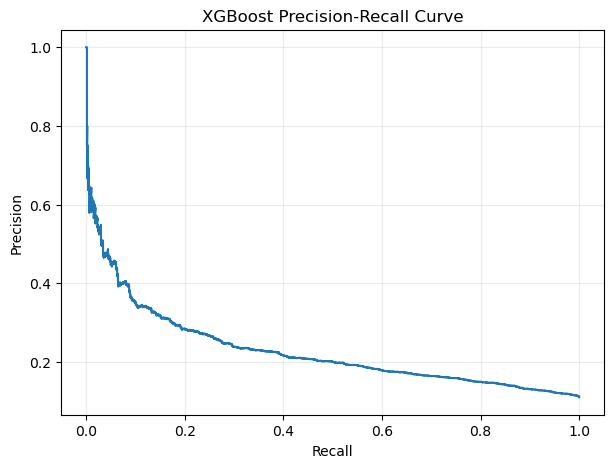

In [33]:
test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test,
    test_prob,
)

plt.figure(figsize=(7, 5))
plt.plot(test_recall_curve, test_precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.grid(alpha=0.25)
plt.show()

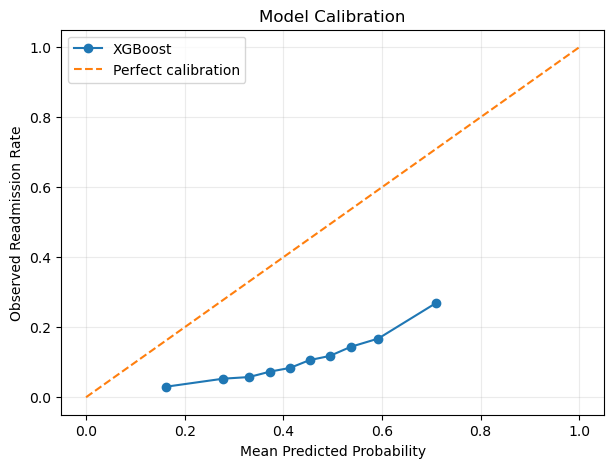

In [34]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_prob,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Model Calibration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Bias Assessment
- Race
- Age
- Gender

The table compares recall, false positive rate, false negative rate, precision, and predicted-positive rate for each group.

## 14. Bias and fairness evaluation

In [35]:
bias_df = sensitive_test.copy()
bias_df["y_true"] = y_test.reset_index(drop=True)
bias_df["y_pred"] = test_pred
bias_df["y_prob"] = test_prob

def calculate_group_metrics(data, group_column):
    rows = []

    for group_value, group in data.groupby(group_column, dropna=False):
        y_true_group = group["y_true"].to_numpy()
        y_pred_group = group["y_pred"].to_numpy()

        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1],
        ).ravel()

        rows.append({
            "group": group_value,
            "count": len(group),
            "readmission_rate": y_true_group.mean(),
            "recall": tp / (tp + fn) if (tp + fn) else np.nan,
            "precision": tp / (tp + fp) if (tp + fp) else np.nan,
            "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) else np.nan,
            "predicted_positive_rate": y_pred_group.mean(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

bias_results = {}

for sensitive_feature in ["race", "age", "gender"]:
    print(f"\n=== {sensitive_feature.upper()} ===")
    result = calculate_group_metrics(
        bias_df,
        sensitive_feature,
    )
    bias_results[sensitive_feature] = result
    display(result.round(4))


=== RACE ===


,group,count,readmission_rate,recall,precision,false_positive_rate,false_negative_rate,predicted_positive_rate
0,Caucasian,11434,0.1126,0.7267,0.1616,0.4787,0.2733,0.5066
1,AfricanAmerican,2880,0.1069,0.7208,0.1606,0.4510,0.2792,0.4799
2,Unknown,331,0.0755,0.6800,0.1318,0.3660,0.3200,0.3897
3,Hispanic,326,0.1074,0.8571,0.1987,0.4158,0.1429,0.4632
4,Other,218,0.0917,0.4500,0.1125,0.3586,0.5500,0.3670
5,Asian,89,0.0899,0.8750,0.2500,0.2593,0.1250,0.3146



=== AGE ===


,group,count,readmission_rate,recall,precision,false_positive_rate,false_negative_rate,predicted_positive_rate
0,[70-80),3917,0.1246,0.7725,0.1711,0.5328,0.2275,0.5627
1,[60-70),3440,0.1073,0.6883,0.1461,0.4836,0.3117,0.5055
2,[80-90),2586,0.1102,0.8000,0.1401,0.6080,0.2000,0.6292
3,[50-60),2574,0.0967,0.6908,0.1857,0.3243,0.3092,0.3598
4,[40-50),1486,0.1030,0.7190,0.1846,0.3646,0.2810,0.4011
5,[30-40),533,0.1032,0.5091,0.1573,0.3138,0.4909,0.3340
6,[90-100),403,0.1241,0.6800,0.1650,0.4873,0.3200,0.5112
7,[20-30),217,0.1290,0.6429,0.2432,0.2963,0.3571,0.3410
8,[10-20),101,0.0594,0.0000,0.0000,0.1368,1.0000,0.1287
9,[0-10),21,0.0476,0.0000,NaN,0.0000,1.0000,0.0000



=== GENDER ===


,group,count,readmission_rate,recall,precision,false_positive_rate,false_negative_rate,predicted_positive_rate
0,Female,8340,0.1132,0.7479,0.1640,0.4866,0.2521,0.5162
1,Male,6938,0.1067,0.6959,0.1581,0.4426,0.3041,0.4696


# Model Registration

The final trained XGBoost model, preprocessing object, evaluation report, bias results, and feature metadata are saved as artifacts.

## 15. Save model and evaluation artifacts

In [36]:
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    artifact_dir / "preprocessor.joblib",
)

# Save native XGBoost model for SageMaker XGBoost serving
native_model_path = artifact_dir / "xgboost-model"
best_model.get_booster().save_model(native_model_path)

with open(
    artifact_dir / "transformed_feature_names.json",
    "w",
) as f:
    json.dump(
        transformed_feature_names,
        f,
        indent=2,
    )

evaluation_report = {
    "model": "XGBoost",
    "primary_metrics": [
        "recall",
        "precision_recall_auc",
    ],
    "test_metrics": test_metrics,
    "decision_threshold": decision_threshold,
    "selected_candidate": best_candidate,
    "raw_model_features": feature_cols,
    "transformed_feature_count": len(transformed_feature_names),
}

with open(
    artifact_dir / "evaluation.json",
    "w",
) as f:
    json.dump(
        evaluation_report,
        f,
        indent=2,
    )

for sensitive_feature, result in bias_results.items():
    result.to_csv(
        artifact_dir / f"bias_{sensitive_feature}.csv",
        index=False,
    )

print("Artifacts saved to:", artifact_dir.resolve())

Artifacts saved to: /home/sagemaker-user/diabetes-readmission-prediction/notebooks/training/artifacts


## 16. Package and upload model artifacts to S3

In [38]:
model_tar_path = artifact_dir / "model.tar.gz"

MODEL_PREFIX = f"{PROJECT_PREFIX}/model-artifacts"
MODEL_PACKAGE_GROUP = "CarePath-Diabetes-Readmission"

with tarfile.open(
    model_tar_path,
    "w:gz",
) as tar:
    tar.add(
        native_model_path,
        arcname="xgboost-model",
    )

model_s3_uri = session.upload_data(
    path=str(model_tar_path),
    bucket=bucket,
    key_prefix=f"{MODEL_PREFIX}/model",
)

evaluation_s3_uri = session.upload_data(
    path=str(artifact_dir / "evaluation.json"),
    bucket=bucket,
    key_prefix=f"{MODEL_PREFIX}/evaluation",
)

preprocessor_s3_uri = session.upload_data(
    path=str(artifact_dir / "preprocessor.joblib"),
    bucket=bucket,
    key_prefix=f"{MODEL_PREFIX}/preprocessing",
)

print("Model:", model_s3_uri)
print("Evaluation:", evaluation_s3_uri)
print("Preprocessor:", preprocessor_s3_uri)

Model: s3://sagemaker-us-east-1-545290732881/carepath-analytics/model-artifacts/model/model.tar.gz
Evaluation: s3://sagemaker-us-east-1-545290732881/carepath-analytics/model-artifacts/evaluation/evaluation.json
Preprocessor: s3://sagemaker-us-east-1-545290732881/carepath-analytics/model-artifacts/preprocessing/preprocessor.joblib


## 17. Register model in SageMaker Model Registry

In [43]:
from botocore.exceptions import ClientError
from sagemaker import image_uris
sm_client = boto3.client(
    "sagemaker",
    region_name=region
)

MODEL_PACKAGE_GROUP = "CarePath-Diabetes-Readmission"

print("Region:", region)
print("Bucket:", bucket)
print("Model Package Group:", MODEL_PACKAGE_GROUP)

try:
    sm_client.describe_model_package_group(
        ModelPackageGroupName=MODEL_PACKAGE_GROUP
    )
    print("Model package group already exists.")
except ClientError as e:
    if e.response["Error"]["Code"] == "ValidationException":
        sm_client.create_model_package_group(
            ModelPackageGroupName=MODEL_PACKAGE_GROUP,
            ModelPackageGroupDescription=(
                "CarePath Analytics diabetes 30-day readmission models"
            ),
        )
        print("Created model package group.")
    else:
        raise

xgboost_image = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="3.0-5",
)

register_response = sm_client.create_model_package(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    ModelPackageDescription=(
        "XGBoost model for diabetic patient 30-day readmission prediction"
    ),
    InferenceSpecification={
        "Containers": [
            {
                "Image": xgboost_image,
                "ModelDataUrl": model_s3_uri,
            }
        ],
        "SupportedContentTypes": ["text/csv"],
        "SupportedResponseMIMETypes": ["text/csv"],
    },
    ModelApprovalStatus="PendingManualApproval",
    ModelMetrics={
        "ModelQuality": {
            "Statistics": {
                "ContentType": "application/json",
                "S3Uri": evaluation_s3_uri,
            }
        }
    },
)

model_package_arn = register_response["ModelPackageArn"]

print("Model package ARN:")
print(model_package_arn)
print("Approval status: PendingManualApproval")

Region: us-east-1
Bucket: sagemaker-us-east-1-545290732881
Model Package Group: CarePath-Diabetes-Readmission
Model package group already exists.
Model package ARN:
arn:aws:sagemaker:us-east-1:545290732881:model-package/CarePath-Diabetes-Readmission/1
Approval status: PendingManualApproval
